# EDA — Dataset 113: Clasificación de Peso (`clas_peso`)
**Proyecto de grado** | Fase 2 CRISP-DM: Entendimiento de los Datos  
Variable objetivo: `clas_peso` | Dataset: `113_limpio_unificado.csv`

---
## Contenido
1. Carga y resumen general
2. Distribución de `clas_peso` (variable objetivo)
3. Análisis por edad
4. Análisis por sexo
5. Análisis por año
6. Análisis por municipio y departamento
7. Análisis socioeconómico (estrato)
8. Análisis étnico
9. Correlación de variables — clínicas, geográficas y socioeconómicas
10. Pruebas de normalidad (Shapiro-Wilk / Kolmogorov-Smirnov)
11. Análisis ANOVA — significancia estadística
12. Estadísticas descriptivas detalladas por clase de peso
13. Hallazgos y próximos pasos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

COLORES_CLASE = {
    'Desnut. severa'   : '#c0392b',
    'Desnut. moderada' : '#e67e22',
    'Normal'           : '#27ae60',
    'Riesgo sobrepeso' : '#2980b9',
    'Sobrepeso'        : '#8e44ad',
    'Obesidad'         : '#16a085'
}
ORDEN         = list(COLORES_CLASE.keys())
COLORES_LISTA = list(COLORES_CLASE.values())

---
## 1. Carga y resumen general

In [2]:
df = pd.read_csv('../data/processed/113_limpio_unificado.csv')

MAPA_PESO = {1: 'Desnut. severa', 2: 'Desnut. moderada', 3: 'Normal',
             4: 'Riesgo sobrepeso', 5: 'Sobrepeso', 6: 'Obesidad'}
df['clas_peso_label'] = df['clas_peso'].map(MAPA_PESO)
df['desnutrido']      = df['clas_peso'].isin([1, 2])

print(f'Registros totales : {len(df):,}')
print(f'Columnas          : {df.shape[1]}')
print(f'Años              : {sorted(df["anio"].unique())}')
print(f'Municipios únicos : {df["municipio_origen"].nunique()}')
if 'depto_origen' in df.columns:
    print(f'Departamentos     : {df["depto_origen"].nunique()}')
print()
print('Nulos en columnas clave:')
cols_clave = ['clas_peso', 'peso_nac', 'talla_nac', 'edad_ges', 'peso_act',
              'talla_act', 'per_braqui', 'imc', 'zscore_pt', 'zscore_te',
              'estrato_', 'sexo_', 'per_etn_']
cols_presentes = [c for c in cols_clave if c in df.columns]
print(df[cols_presentes].isnull().sum().rename('Nulos').to_string())

Registros totales : 2,448
Columnas          : 38
Años              : [np.int64(2023), np.int64(2024), np.int64(2025)]
Municipios únicos : 36
Departamentos     : 9

Nulos en columnas clave:
clas_peso        9
peso_nac         0
talla_nac     1510
edad_ges         0
peso_act         0
talla_act        0
per_braqui     228
imc              0
zscore_pt        0
zscore_te        0
estrato_         0
sexo_            0
per_etn_         0


---
## 2. Distribución de `clas_peso` (variable objetivo)

**Interpretación:** Muestra cuántos casos hay por categoría de peso.  
Revela el fuerte desbalance del dataset — más del 85% son casos de desnutrición.  
Este desbalance es crítico para el modelado: se requerirá SMOTE o `class_weight='balanced'`.

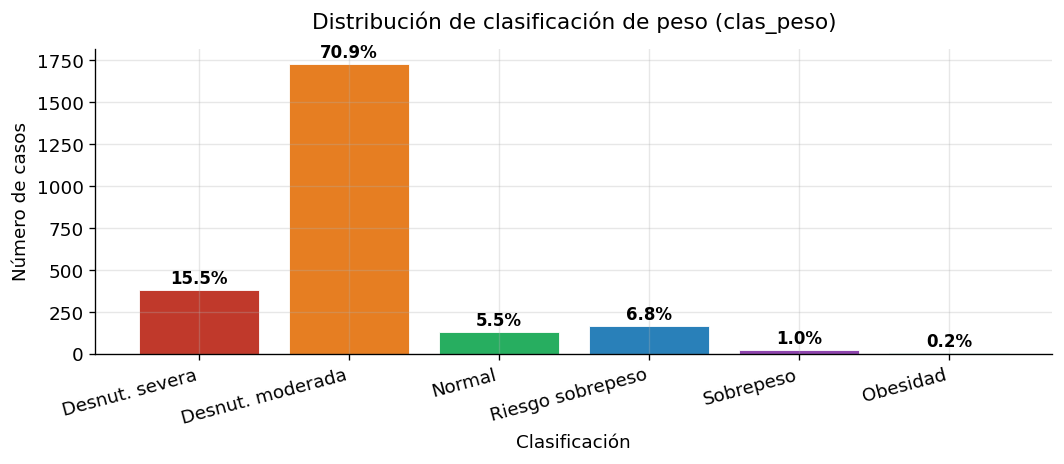

                  Casos  Porcentaje (%)
clas_peso_label                        
Desnut. severa      379           15.54
Desnut. moderada   1730           70.93
Normal              133            5.45
Riesgo sobrepeso    167            6.85
Sobrepeso            24            0.98
Obesidad              6            0.25

Desbalance: 86.5% con algún tipo de desnutrición
Implicación para modelado: se requiere SMOTE o class_weight en los algoritmos.


In [3]:
conteo     = df['clas_peso_label'].value_counts().reindex(ORDEN)
porcentaje = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(ORDEN, conteo.values, color=COLORES_LISTA, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, porcentaje.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribución de clasificación de peso (clas_peso)', fontsize=13, pad=12)
ax.set_xlabel('Clasificación')
ax.set_ylabel('Número de casos')
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
plt.tight_layout()
plt.show()

resumen = pd.DataFrame({'Casos': conteo, 'Porcentaje (%)': porcentaje.round(2)})
print(resumen.to_string())
pct_desnut = porcentaje['Desnut. severa'] + porcentaje['Desnut. moderada']
print(f'\nDesbalance: {pct_desnut:.1f}% con algún tipo de desnutrición')
print('Implicación para modelado: se requiere SMOTE o class_weight en los algoritmos.')

---
## 3. Análisis por edad

**Interpretación:** Se analizan grupos etarios estándar OMS para menores de 5 años.  
Los outliers en el boxplot son niños en edades atípicas dentro de cada clase — no son errores,  
son casos reales que se encuentran en el extremo de la distribución de su grupo.

In [4]:
df['edad_meses'] = df.apply(
    lambda r: r['edad_'] * 12 if r['uni_med_'] == 1 else r['edad_'], axis=1
)
bins   = [0, 5, 11, 23, 35, 47, 60]
labels = ['0-5m', '6-11m', '12-23m', '24-35m', '36-47m', '48-59m']
df['grupo_edad'] = pd.cut(df['edad_meses'], bins=bins, labels=labels, right=True)

ge     = df['grupo_edad'].value_counts().sort_index()
pct_ge = ge / ge.sum() * 100
print('Distribución por grupo etario (grupos OMS):')
print(pd.DataFrame({'Casos': ge, 'Porcentaje (%)': pct_ge.round(2)}).to_string())

Distribución por grupo etario (grupos OMS):
            Casos  Porcentaje (%)
grupo_edad                       
0-5m          183            7.48
6-11m         435           17.77
12-23m       1133           46.28
24-35m        375           15.32
36-47m        177            7.23
48-59m        145            5.92


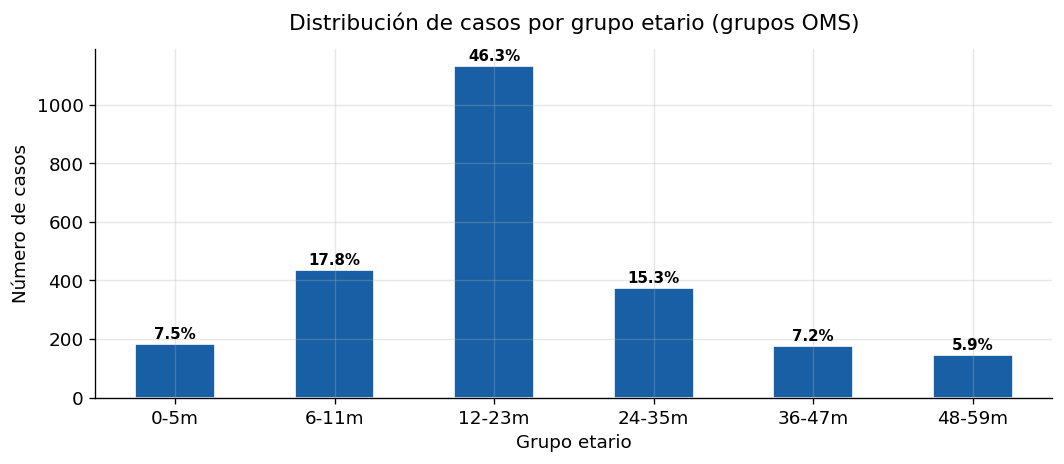

El grupo 12-23 meses concentra la mayor cantidad de casos.
Este período corresponde al destete y transición alimentaria, etapa de mayor riesgo nutricional.


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ge.plot(kind='bar', ax=ax, color='#185fa5', edgecolor='white')
for p, v in zip(ax.patches, pct_ge.values):
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 8,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Distribución de casos por grupo etario (grupos OMS)', fontsize=13, pad=12)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Número de casos')
ax.set_xticklabels(labels, rotation=0)
plt.tight_layout()
plt.show()
print('El grupo 12-23 meses concentra la mayor cantidad de casos.')
print('Este período corresponde al destete y transición alimentaria, etapa de mayor riesgo nutricional.')

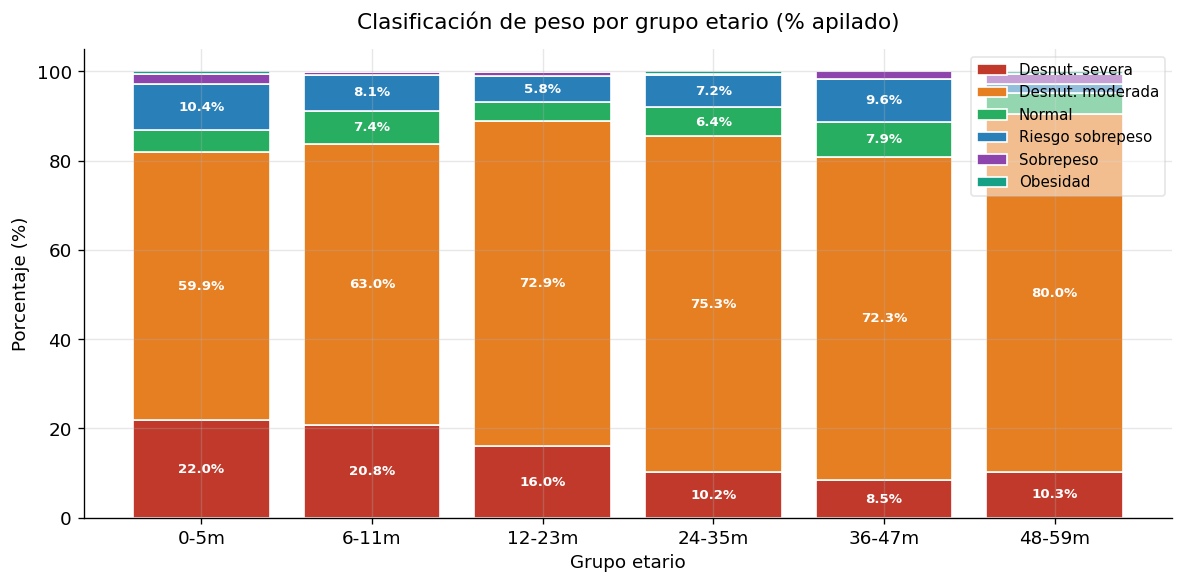

Tabla % de clas_peso por grupo etario:
clas_peso_label  Desnut. severa  Desnut. moderada  Normal  Riesgo sobrepeso  Sobrepeso  Obesidad
grupo_edad                                                                                      
0-5m                      21.98             59.89    4.95             10.44       2.20      0.55
6-11m                     20.79             63.05    7.39              8.08       0.46      0.23
12-23m                    16.03             72.90    4.16              5.85       0.97      0.09
24-35m                    10.19             75.34    6.43              7.24       0.27      0.54
36-47m                     8.47             72.32    7.91              9.60       1.69      0.00
48-59m                    10.34             80.00    4.83              2.07       2.07      0.69


In [6]:
tabla_edad = pd.crosstab(df['grupo_edad'], df['clas_peso_label']).reindex(columns=ORDEN, fill_value=0)
tabla_pct  = tabla_edad.div(tabla_edad.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom  = np.zeros(len(tabla_pct))
for col, color in zip(ORDEN, COLORES_LISTA):
    vals = tabla_pct[col].values
    bars = ax.bar(tabla_pct.index.astype(str), vals, bottom=bottom,
                  color=color, edgecolor='white', label=col)
    for bar, v in zip(bars, vals):
        if v > 5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals
ax.set_title('Clasificación de peso por grupo etario (% apilado)', fontsize=13, pad=12)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', framealpha=0.5, fontsize=9)
plt.tight_layout()
plt.show()
print('Tabla % de clas_peso por grupo etario:')
print(tabla_pct.round(2).to_string())

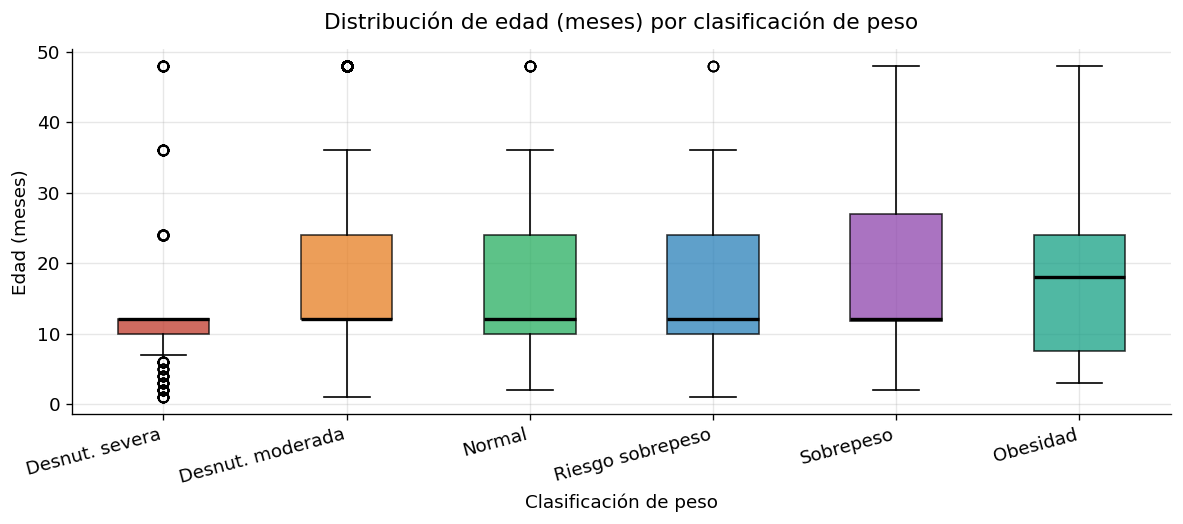

Mediana de edad (meses) por clase:
clas_peso_label
Desnut. severa      12.0
Desnut. moderada    12.0
Normal              12.0
Riesgo sobrepeso    12.0
Sobrepeso           12.0
Obesidad            18.0

Las medianas similares (~12 meses) en la mayoría de clases indican
que la edad sola no discrimina bien entre categorías de peso.
Los outliers son niños en edades atípicas para su clase — casos reales, no errores de datos.


In [7]:
grupos_edad = [df.loc[df['clas_peso_label'] == c, 'edad_meses'].dropna().values for c in ORDEN]
fig, ax = plt.subplots(figsize=(10, 4.5))
bp = ax.boxplot(grupos_edad, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORES_LISTA):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(ORDEN) + 1))
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_title('Distribución de edad (meses) por clasificación de peso', fontsize=13, pad=12)
ax.set_xlabel('Clasificación de peso')
ax.set_ylabel('Edad (meses)')
plt.tight_layout()
plt.show()
print('Mediana de edad (meses) por clase:')
print(df.groupby('clas_peso_label')['edad_meses'].median().reindex(ORDEN).round(1).to_string())
print()
print('Las medianas similares (~12 meses) en la mayoría de clases indican')
print('que la edad sola no discrimina bien entre categorías de peso.')
print('Los outliers son niños en edades atípicas para su clase — casos reales, no errores de datos.')

---
## 4. Análisis por sexo

**Interpretación:** Se usan tasas (porcentajes), no números absolutos,  
porque hay más niños que niñas en el dataset.  
Comparar valores absolutos entre grupos de distinto tamaño es estadísticamente incorrecto.

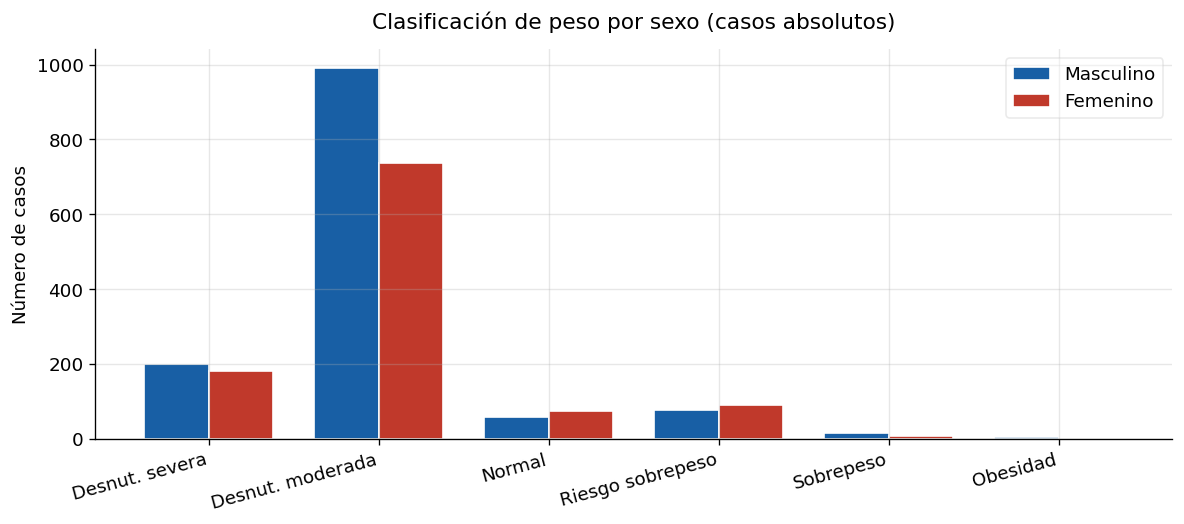

Tabla absoluta:
sexo_               F    M
clas_peso_label           
Desnut. severa    180  199
Desnut. moderada  738  992
Normal             74   59
Riesgo sobrepeso   91   76
Sobrepeso           8   16
Obesidad            0    6

Tabla porcentual (base = total de cada sexo):
sexo_                 F      M
clas_peso_label               
Desnut. severa    16.50  14.76
Desnut. moderada  67.64  73.59
Normal             6.78   4.38
Riesgo sobrepeso   8.34   5.64
Sobrepeso          0.73   1.19
Obesidad           0.00   0.45

Aunque en números absolutos hay más niños con desnutrición,
la tasa en niñas es levemente mayor porque el total de niñas en el dataset es menor.
Para comparar entre grupos de distinto tamaño siempre se usan porcentajes.


In [8]:
tabla_sexo     = pd.crosstab(df['clas_peso_label'], df['sexo_']).reindex(ORDEN)
tabla_sexo_pct = tabla_sexo.div(tabla_sexo.sum(axis=0), axis=1) * 100

x, width = np.arange(len(ORDEN)), 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, tabla_sexo.get('M', 0), width, label='Masculino', color='#185fa5', edgecolor='white')
ax.bar(x + width/2, tabla_sexo.get('F', 0), width, label='Femenino',  color='#c0392b', edgecolor='white')
ax.set_title('Clasificación de peso por sexo (casos absolutos)', fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_ylabel('Número de casos')
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.show()

print('Tabla absoluta:')
print(tabla_sexo.to_string())
print('\nTabla porcentual (base = total de cada sexo):')
print(tabla_sexo_pct.round(2).to_string())
print()
print('Aunque en números absolutos hay más niños con desnutrición,')
print('la tasa en niñas es levemente mayor porque el total de niñas en el dataset es menor.')
print('Para comparar entre grupos de distinto tamaño siempre se usan porcentajes.')

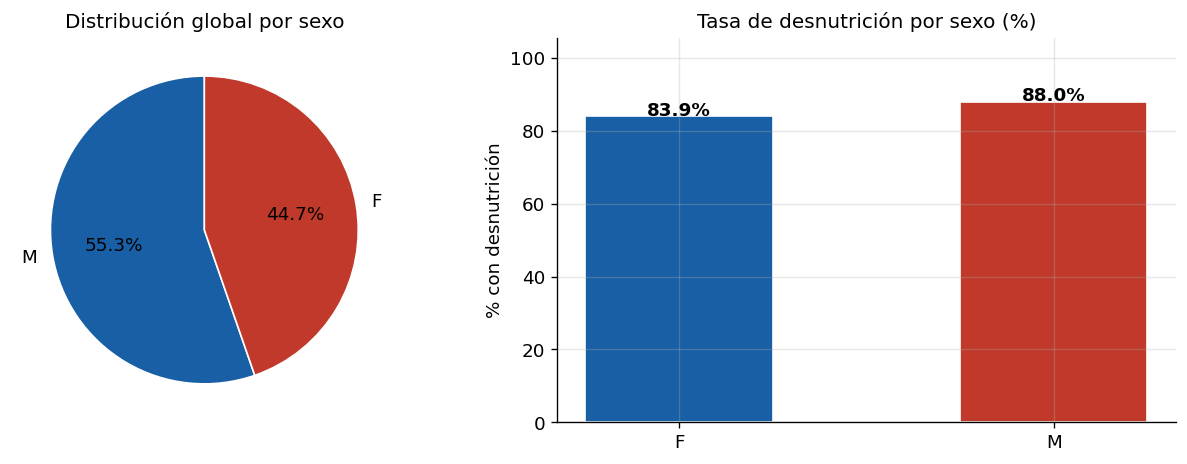

In [9]:
sexo_conteo      = df['sexo_'].value_counts()
tasa_desnut_sexo = df.groupby('sexo_')['desnutrido'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(sexo_conteo.values, labels=sexo_conteo.index,
            autopct='%1.1f%%', colors=['#185fa5', '#c0392b'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Distribución global por sexo', fontsize=12)

axes[1].bar(tasa_desnut_sexo.index, tasa_desnut_sexo.values,
            color=['#185fa5', '#c0392b'], edgecolor='white', width=0.5)
for i, (idx, val) in enumerate(tasa_desnut_sexo.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Tasa de desnutrición por sexo (%)', fontsize=12)
axes[1].set_ylabel('% con desnutrición')
axes[1].set_ylim(0, tasa_desnut_sexo.max() * 1.2)
plt.tight_layout()
plt.show()

---
## 5. Análisis por año

**Interpretación:** El año 2023 tiene solo 97 registros (posible captura parcial),  
por lo que la comparación de tendencia temporal es válida principalmente entre 2024 y 2025.  
La tasa sostenida en ~86% indica que la desnutrición no mejoró entre esos dos años.  
La diferencia en número de casos absolutos no afecta la tasa — son medidas distintas.

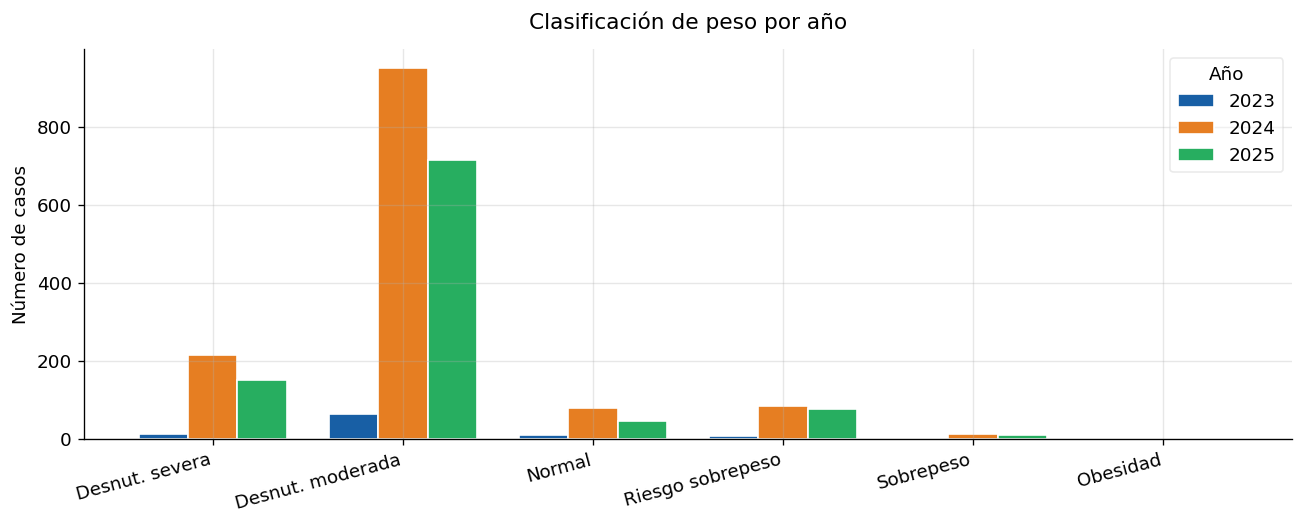

Tabla absoluta por año:
anio              2023  2024  2025
clas_peso_label                   
Desnut. severa      13   215   151
Desnut. moderada    64   951   715
Normal               9    78    46
Riesgo sobrepeso     7    84    76
Sobrepeso            3    11    10
Obesidad             1     2     3


In [10]:
anios        = sorted(df['anio'].unique())
tabla_anio   = pd.crosstab(df['clas_peso_label'], df['anio']).reindex(ORDEN)
colores_anio = ['#185fa5', '#e67e22', '#27ae60']

x, width, n_anios = np.arange(len(ORDEN)), 0.26, len(anios)
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (anio, color) in enumerate(zip(anios, colores_anio)):
    offset = (i - (n_anios - 1) / 2) * width
    ax.bar(x + offset, tabla_anio.get(anio, 0), width, label=str(anio), color=color, edgecolor='white')
ax.set_title('Clasificación de peso por año', fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ORDEN, rotation=15, ha='right')
ax.set_ylabel('Número de casos')
ax.legend(title='Año', framealpha=0.4)
plt.tight_layout()
plt.show()
print('Tabla absoluta por año:')
print(tabla_anio.to_string())

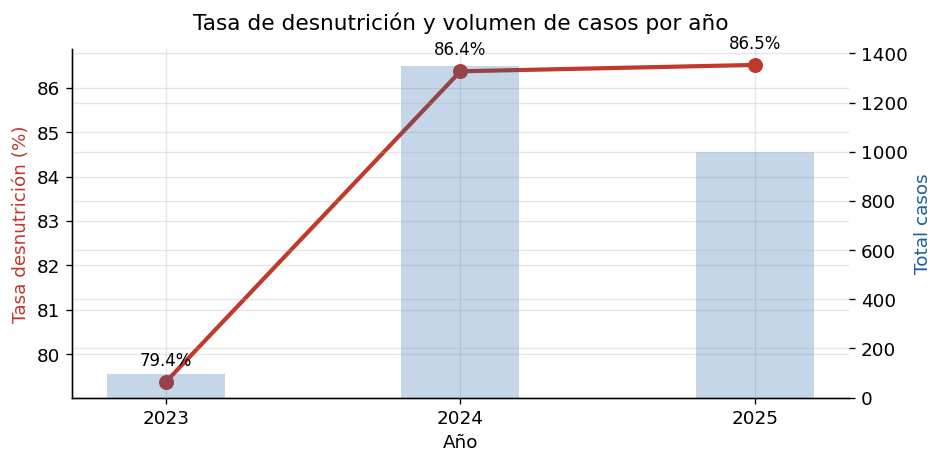

Total de casos por año:
anio
2023      97
2024    1350
2025    1001

Tasa de desnutrición por año (%):
anio
2023    79.38
2024    86.37
2025    86.51

Nota: 2023 solo tiene 97 registros — posible captura parcial del año.
La comparación de tendencia es válida principalmente entre 2024 y 2025.
La tasa sostenida en ~86% indica que la desnutrición no mejoró entre ambos años.


In [11]:
tasa_anio  = df.groupby('anio')['desnutrido'].mean() * 100
total_anio = df.groupby('anio').size()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(tasa_anio.index, tasa_anio.values, 'o-', color='#c0392b', linewidth=2.5, markersize=8)
for x_val, y_val in zip(tasa_anio.index, tasa_anio.values):
    ax1.annotate(f'{y_val:.1f}%', (x_val, y_val),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
ax2.bar(total_anio.index, total_anio.values, color='#185fa5', alpha=0.25, width=0.4)
ax1.set_title('Tasa de desnutrición y volumen de casos por año', fontsize=13, pad=12)
ax1.set_xlabel('Año')
ax1.set_ylabel('Tasa desnutrición (%)', color='#c0392b')
ax2.set_ylabel('Total casos', color='#185fa5')
ax1.set_xticks(anios)
plt.tight_layout()
plt.show()
print('Total de casos por año:')
print(total_anio.to_string())
print('\nTasa de desnutrición por año (%):')
print(tasa_anio.round(2).to_string())
print()
print('Nota: 2023 solo tiene 97 registros — posible captura parcial del año.')
print('La comparación de tendencia es válida principalmente entre 2024 y 2025.')
print('La tasa sostenida en ~86% indica que la desnutrición no mejoró entre ambos años.')

---
## 6. Análisis por municipio y departamento

**Interpretación:** Se filtran municipios con menos de 20 casos para que las tasas sean  
estadísticamente representativas. Con pocos casos, una tasa del 100% no es informativa —  
puede ser simplemente que los 2 o 3 casos registrados en ese municipio son todos desnutrición.

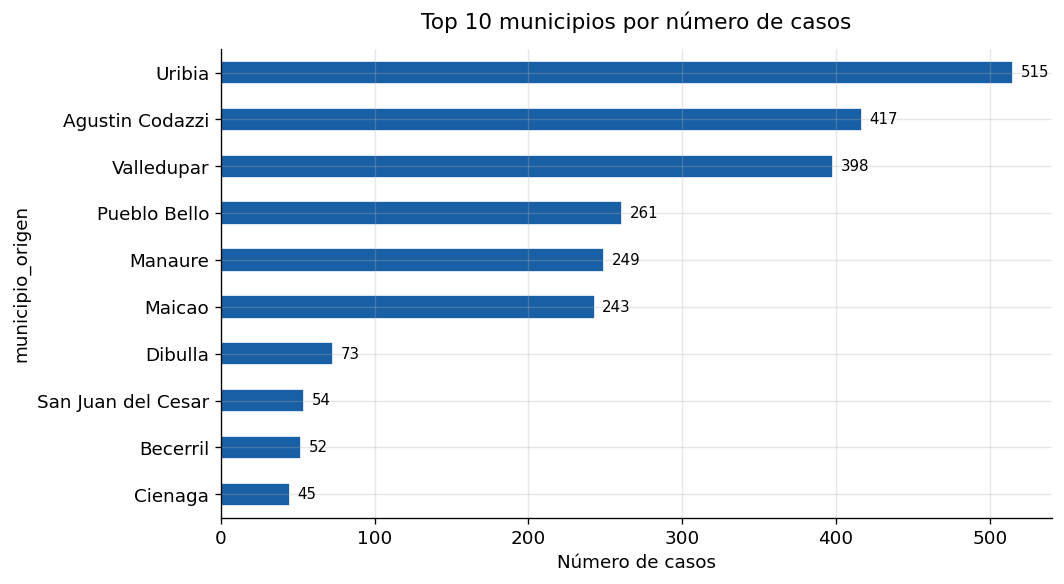

Valledupar concentra el mayor volumen por ser la capital del Cesar.
Uribia y Manaure (La Guajira) tienen alto volumen asociado a población Wayuu.


In [12]:
top10_mun = df['municipio_origen'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
top10_mun[::-1].plot(kind='barh', ax=ax, color='#185fa5', edgecolor='white')
for p in ax.patches:
    ax.text(p.get_width() + 5, p.get_y() + p.get_height() / 2,
            f'{int(p.get_width()):,}', va='center', fontsize=9)
ax.set_title('Top 10 municipios por número de casos', fontsize=13, pad=12)
ax.set_xlabel('Número de casos')
plt.tight_layout()
plt.show()
print('Valledupar concentra el mayor volumen por ser la capital del Cesar.')
print('Uribia y Manaure (La Guajira) tienen alto volumen asociado a población Wayuu.')

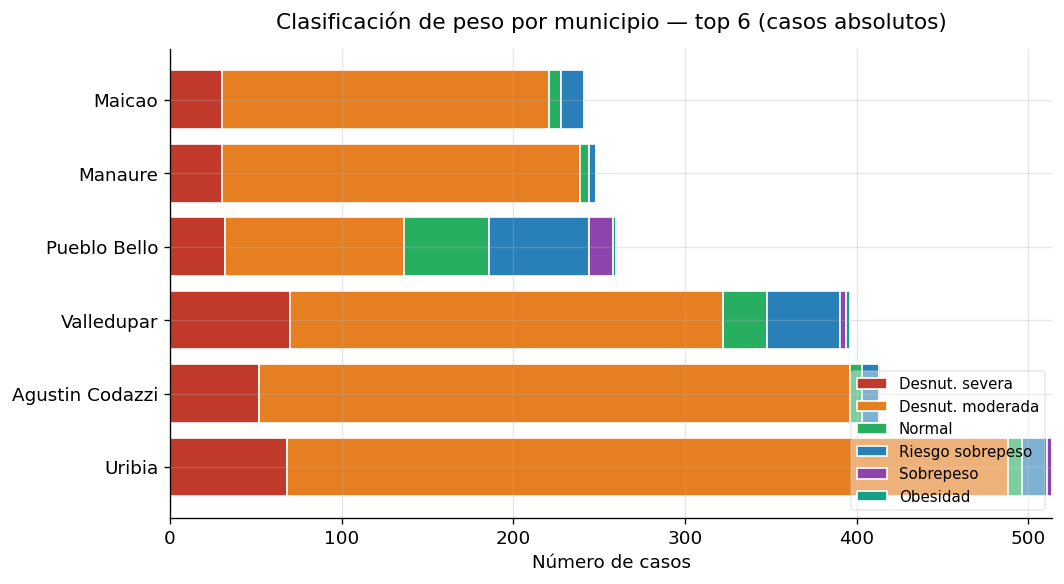

Tabla absoluta:
clas_peso_label   Desnut. severa  Desnut. moderada  Normal  Riesgo sobrepeso  Sobrepeso  Obesidad
municipio_origen                                                                                 
Uribia                        68               420       8                15          3         0
Agustin Codazzi               52               344       7                10          1         1
Valledupar                    70               252      26                42          4         2
Pueblo Bello                  32               104      50                58         14         2
Manaure                       30               209       5                 4          0         0
Maicao                        30               191       7                13          1         0


In [13]:
top6_mun  = df['municipio_origen'].value_counts().head(6).index.tolist()
df_mun    = df[df['municipio_origen'].isin(top6_mun)].copy()
tabla_mun = pd.crosstab(df_mun['municipio_origen'], df_mun['clas_peso_label'])
tabla_mun = tabla_mun.reindex(columns=ORDEN, fill_value=0).loc[top6_mun]

fig, ax = plt.subplots(figsize=(9, 5))
left = np.zeros(len(tabla_mun))
for col, color in zip(ORDEN, COLORES_LISTA):
    ax.barh(tabla_mun.index, tabla_mun[col], left=left, color=color, edgecolor='white', label=col)
    left += tabla_mun[col].values
ax.set_title('Clasificación de peso por municipio — top 6 (casos absolutos)', fontsize=13, pad=12)
ax.set_xlabel('Número de casos')
ax.legend(loc='lower right', framealpha=0.4, fontsize=9)
plt.tight_layout()
plt.show()
print('Tabla absoluta:')
print(tabla_mun.to_string())

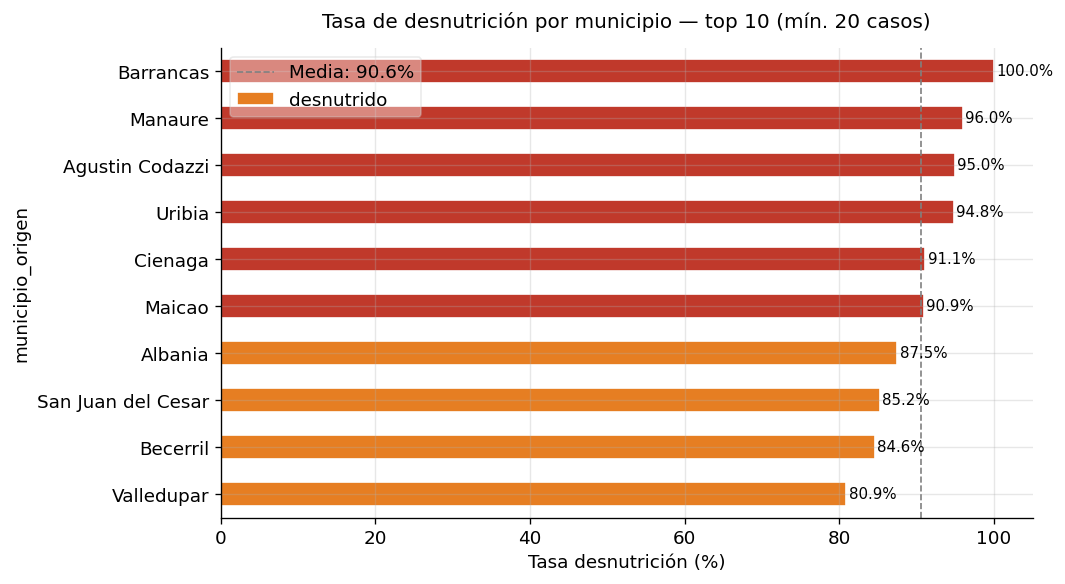

Tasa de desnutrición (%) — top 10 municipios:
municipio_origen
Barrancas             100.00
Manaure                95.98
Agustin Codazzi        94.96
Uribia                 94.76
Cienaga                91.11
Maicao                 90.95
Albania                87.50
San Juan del Cesar     85.19
Becerril               84.62
Valledupar             80.90


In [14]:
MIN_CASOS   = 20
conteo_mun  = df.groupby('municipio_origen').size()
mun_validos = conteo_mun[conteo_mun >= MIN_CASOS].index

tasa_mun = (df[df['municipio_origen'].isin(mun_validos)]
            .groupby('municipio_origen')['desnutrido']
            .mean().mul(100).sort_values(ascending=False))
tasa_mun_top10 = tasa_mun.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colores_bar = ['#c0392b' if v >= tasa_mun_top10.mean() else '#e67e22' for v in tasa_mun_top10.values]
tasa_mun_top10[::-1].plot(kind='barh', ax=ax, color=colores_bar[::-1], edgecolor='white')
for p in ax.patches:
    ax.text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
            f'{p.get_width():.1f}%', va='center', fontsize=9)
ax.axvline(tasa_mun_top10.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Media: {tasa_mun_top10.mean():.1f}%')
ax.set_title('Tasa de desnutrición por municipio — top 10 (mín. 20 casos)', fontsize=12, pad=12)
ax.set_xlabel('Tasa desnutrición (%)')
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.show()
print('Tasa de desnutrición (%) — top 10 municipios:')
print(tasa_mun_top10.round(2).to_string())

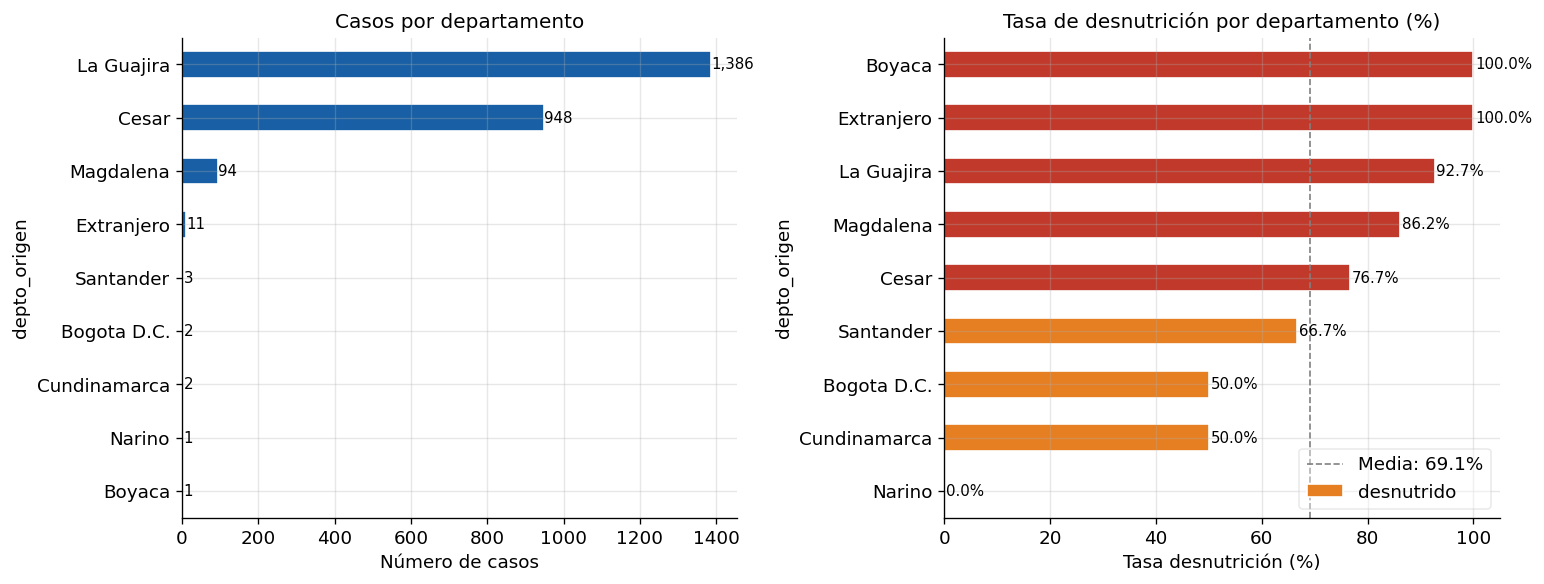

La Guajira históricamente presenta tasas más altas asociadas a la crisis nutricional Wayuu.


In [15]:
if 'depto_origen' in df.columns:
    conteo_dpto = df['depto_origen'].value_counts()
    tasa_dpto   = df.groupby('depto_origen')['desnutrido'].mean().mul(100).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    conteo_dpto[::-1].plot(kind='barh', ax=axes[0], color='#185fa5', edgecolor='white')
    for p in axes[0].patches:
        axes[0].text(p.get_width() + 2, p.get_y() + p.get_height() / 2,
                     f'{int(p.get_width()):,}', va='center', fontsize=9)
    axes[0].set_title('Casos por departamento', fontsize=12)
    axes[0].set_xlabel('Número de casos')

    colores_dpto = ['#c0392b' if v >= tasa_dpto.mean() else '#e67e22' for v in tasa_dpto.values]
    tasa_dpto[::-1].plot(kind='barh', ax=axes[1], color=colores_dpto[::-1], edgecolor='white')
    for p in axes[1].patches:
        axes[1].text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
                     f'{p.get_width():.1f}%', va='center', fontsize=9)
    axes[1].axvline(tasa_dpto.mean(), color='gray', linestyle='--', linewidth=1,
                    label=f'Media: {tasa_dpto.mean():.1f}%')
    axes[1].set_title('Tasa de desnutrición por departamento (%)', fontsize=12)
    axes[1].set_xlabel('Tasa desnutrición (%)')
    axes[1].legend(framealpha=0.4)
    plt.tight_layout()
    plt.show()
    print('La Guajira históricamente presenta tasas más altas asociadas a la crisis nutricional Wayuu.')
else:
    print('Columna depto_origen no disponible en el dataset.')

---
## 7. Análisis socioeconómico — estrato

**Interpretación:** El estrato es una proxy del nivel de ingresos en Colombia (1=bajo, 6=alto).  
Se espera una relación **inversamente proporcional**: a mayor estrato, menor desnutrición.  
Si la correlación es negativa, confirma esta hipótesis.  
Si es cercana a cero, otros factores (etnia, ubicación) dominan sobre el nivel económico.

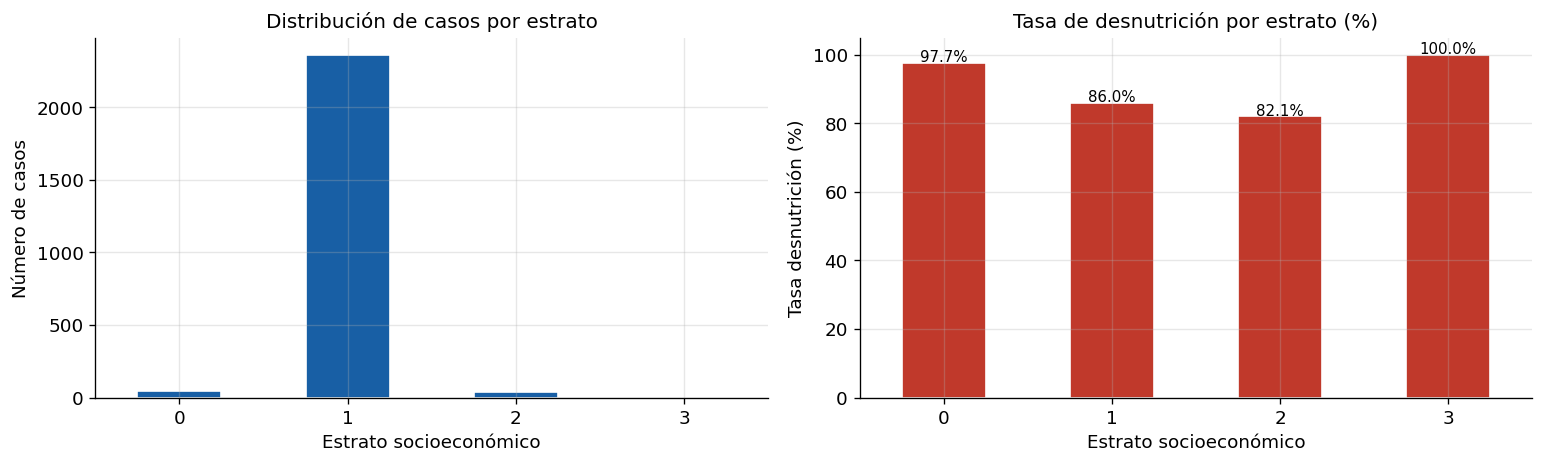

          Casos  Tasa desnutrición (%)
estrato_                              
0            44                  97.73
1          2362                  85.99
2            39                  82.05
3             3                 100.00

Correlación Pearson estrato_ vs clas_peso: 0.0318
Correlación cercana a cero → el estrato tiene poca relación lineal con clas_peso.
Posible explicación: otros factores (etnia, municipio) dominan sobre el nivel económico.


In [16]:
if 'estrato_' in df.columns:
    conteo_estrato = df['estrato_'].value_counts().sort_index()
    tasa_estrato   = df.groupby('estrato_')['desnutrido'].mean().mul(100)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    conteo_estrato.plot(kind='bar', ax=axes[0], color='#185fa5', edgecolor='white')
    axes[0].set_title('Distribución de casos por estrato', fontsize=12)
    axes[0].set_xlabel('Estrato socioeconómico')
    axes[0].set_ylabel('Número de casos')
    axes[0].tick_params(axis='x', rotation=0)

    tasa_estrato.plot(kind='bar', ax=axes[1], color='#c0392b', edgecolor='white')
    for p in axes[1].patches:
        axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 0.3,
                     f'{p.get_height():.1f}%', ha='center', fontsize=9)
    axes[1].set_title('Tasa de desnutrición por estrato (%)', fontsize=12)
    axes[1].set_xlabel('Estrato socioeconómico')
    axes[1].set_ylabel('Tasa desnutrición (%)')
    axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

    print(pd.DataFrame({'Casos': conteo_estrato, 'Tasa desnutrición (%)': tasa_estrato.round(2)}).to_string())

    corr_estrato = df[['estrato_', 'clas_peso']].corr().iloc[0, 1]
    print(f'\nCorrelación Pearson estrato_ vs clas_peso: {corr_estrato:.4f}')
    if corr_estrato < -0.05:
        print('Correlación NEGATIVA → relación INVERSAMENTE proporcional.')
        print('A mayor estrato socioeconómico, menor clasificación de peso (menos desnutrición).')
        print('El nivel económico actúa como factor protector contra la desnutrición.')
    elif corr_estrato > 0.05:
        print('Correlación POSITIVA → relación DIRECTAMENTE proporcional.')
    else:
        print('Correlación cercana a cero → el estrato tiene poca relación lineal con clas_peso.')
        print('Posible explicación: otros factores (etnia, municipio) dominan sobre el nivel económico.')
else:
    print('Columna estrato_ no disponible.')

---
## 8. Análisis étnico

**Interpretación:** La pertenencia étnica puede ser un factor determinante en la desnutrición.  
Comunidades indígenas como los Wayuu enfrentan factores estructurales como acceso limitado  
a agua potable, servicios de salud y seguridad alimentaria, lo que eleva sus tasas.

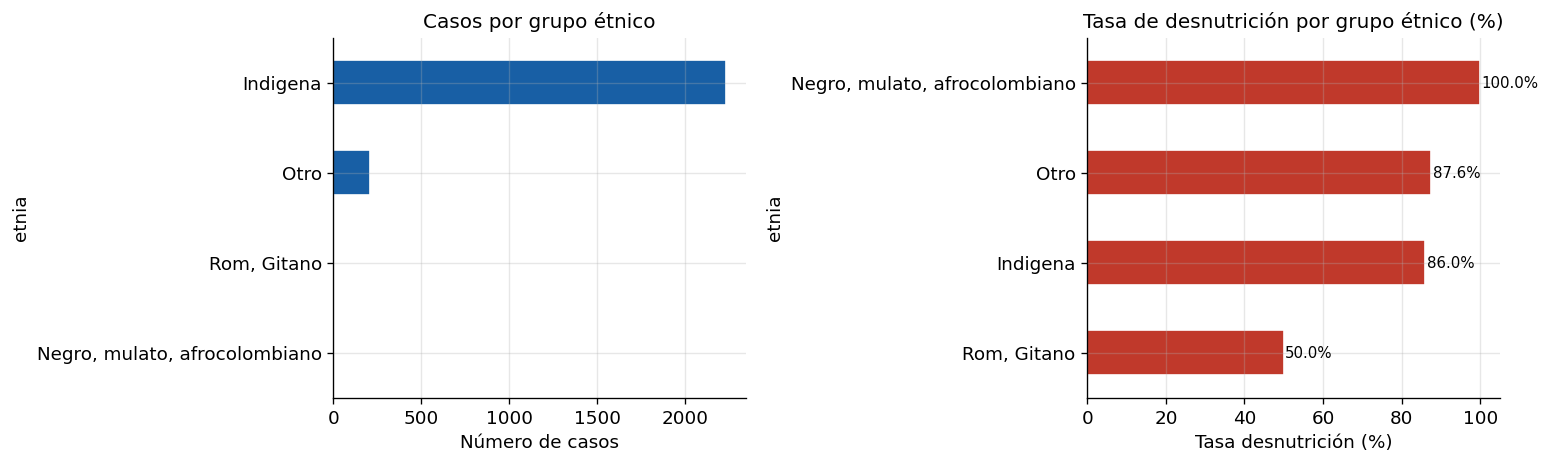

Tasa de desnutrición por grupo étnico (%):
etnia
Negro, mulato, afrocolombiano    100.00
Otro                              87.56
Indigena                          86.05
Rom, Gitano                       50.00

Los grupos indígenas presentan tasas más altas de desnutrición
debido a factores estructurales: acceso limitado a agua potable,
servicios de salud y seguridad alimentaria (especialmente comunidades Wayuu).


In [17]:
col_etnia = 'etnia' if 'etnia' in df.columns else ('per_etn_' if 'per_etn_' in df.columns else None)

if col_etnia:
    conteo_etnia = df[col_etnia].value_counts()
    tasa_etnia   = df.groupby(col_etnia)['desnutrido'].mean().mul(100).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    conteo_etnia[::-1].plot(kind='barh', ax=axes[0], color='#185fa5', edgecolor='white')
    axes[0].set_title('Casos por grupo étnico', fontsize=12)
    axes[0].set_xlabel('Número de casos')

    tasa_etnia[::-1].plot(kind='barh', ax=axes[1], color='#c0392b', edgecolor='white')
    for p in axes[1].patches:
        axes[1].text(p.get_width() + 0.3, p.get_y() + p.get_height() / 2,
                     f'{p.get_width():.1f}%', va='center', fontsize=9)
    axes[1].set_title('Tasa de desnutrición por grupo étnico (%)', fontsize=12)
    axes[1].set_xlabel('Tasa desnutrición (%)')
    plt.tight_layout()
    plt.show()

    print('Tasa de desnutrición por grupo étnico (%):')
    print(tasa_etnia.round(2).to_string())
    print()
    print('Los grupos indígenas presentan tasas más altas de desnutrición')
    print('debido a factores estructurales: acceso limitado a agua potable,')
    print('servicios de salud y seguridad alimentaria (especialmente comunidades Wayuu).')
else:
    print('Columna de etnia no disponible.')

---
## 9. Correlación de variables — clínicas, geográficas y socioeconómicas

**Cómo leer la correlación de Pearson:**  
- Valor **positivo** → relación **directamente proporcional** con `clas_peso`  
  (cuando la variable sube, la clasificación de peso sube también)  
- Valor **negativo** → relación **inversamente proporcional**  
  (cuando la variable sube, la clasificación de peso baja — más desnutrición)  
- Cercano a **0** → sin relación lineal  

**Importante:** La correlación de Pearson mide solo relaciones **lineales**.  
Una variable con r≈0 puede tener relación no lineal con `clas_peso`.  
Para detectar esas relaciones se usa PCA o el feature importance de los árboles de decisión.

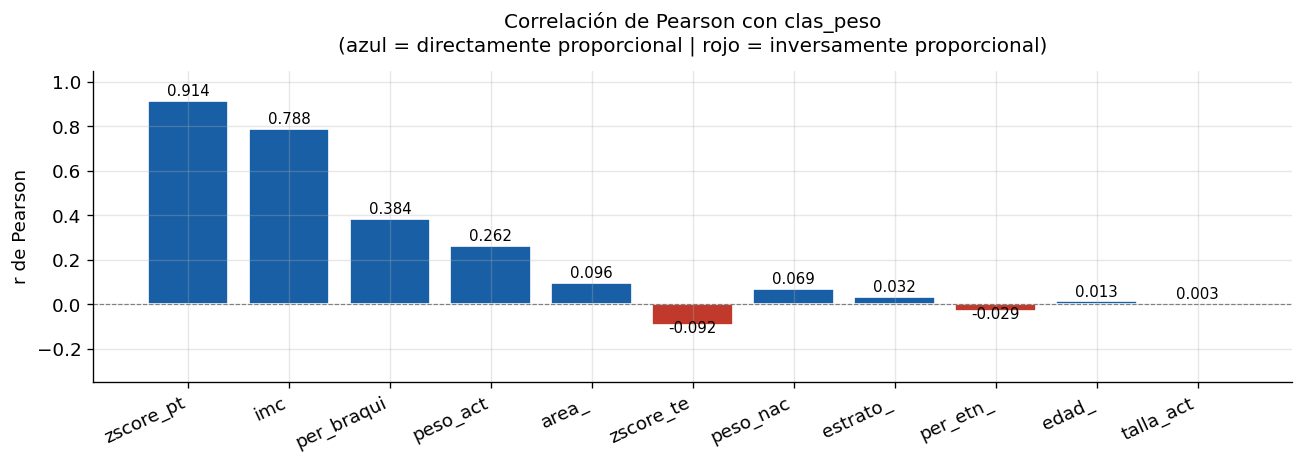

Correlaciones ordenadas por valor absoluto:
zscore_pt     0.9136
imc           0.7883
per_braqui    0.3840
peso_act      0.2617
area_         0.0961
zscore_te    -0.0920
peso_nac      0.0695
estrato_      0.0318
per_etn_     -0.0293
edad_         0.0126
talla_act     0.0035

Directamente proporcionales (positivas):
zscore_pt     0.9136
imc           0.7883
per_braqui    0.3840
peso_act      0.2617
area_         0.0961
peso_nac      0.0695

Inversamente proporcionales (negativas):
zscore_te   -0.092


In [18]:
cols_corr_base = ['zscore_pt', 'imc', 'per_braqui', 'peso_act',
                  'peso_nac', 'zscore_te', 'edad_', 'talla_act']
cols_extra = ['estrato_', 'per_etn_', 'area_']
cols_corr = cols_corr_base + [c for c in cols_extra if c in df.columns]

corr = (df[cols_corr + ['clas_peso']]
        .corr()['clas_peso']
        .drop('clas_peso')
        .sort_values(key=abs, ascending=False))

colores_corr = ['#185fa5' if v >= 0 else '#c0392b' for v in corr.values]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(corr.index, corr.values, color=colores_corr, edgecolor='white')
for bar, val in zip(bars, corr.values):
    y = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.05
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Correlación de Pearson con clas_peso\n(azul = directamente proporcional | rojo = inversamente proporcional)',
             fontsize=12, pad=12)
ax.set_ylabel('r de Pearson')
ax.set_ylim(-0.35, 1.05)
ax.set_xticklabels(corr.index, rotation=25, ha='right')
plt.tight_layout()
plt.show()

print('Correlaciones ordenadas por valor absoluto:')
print(corr.round(4).to_string())
print()
print('Directamente proporcionales (positivas):')
print(corr[corr > 0.05].round(4).to_string())
print()
print('Inversamente proporcionales (negativas):')
print(corr[corr < -0.05].round(4).to_string())

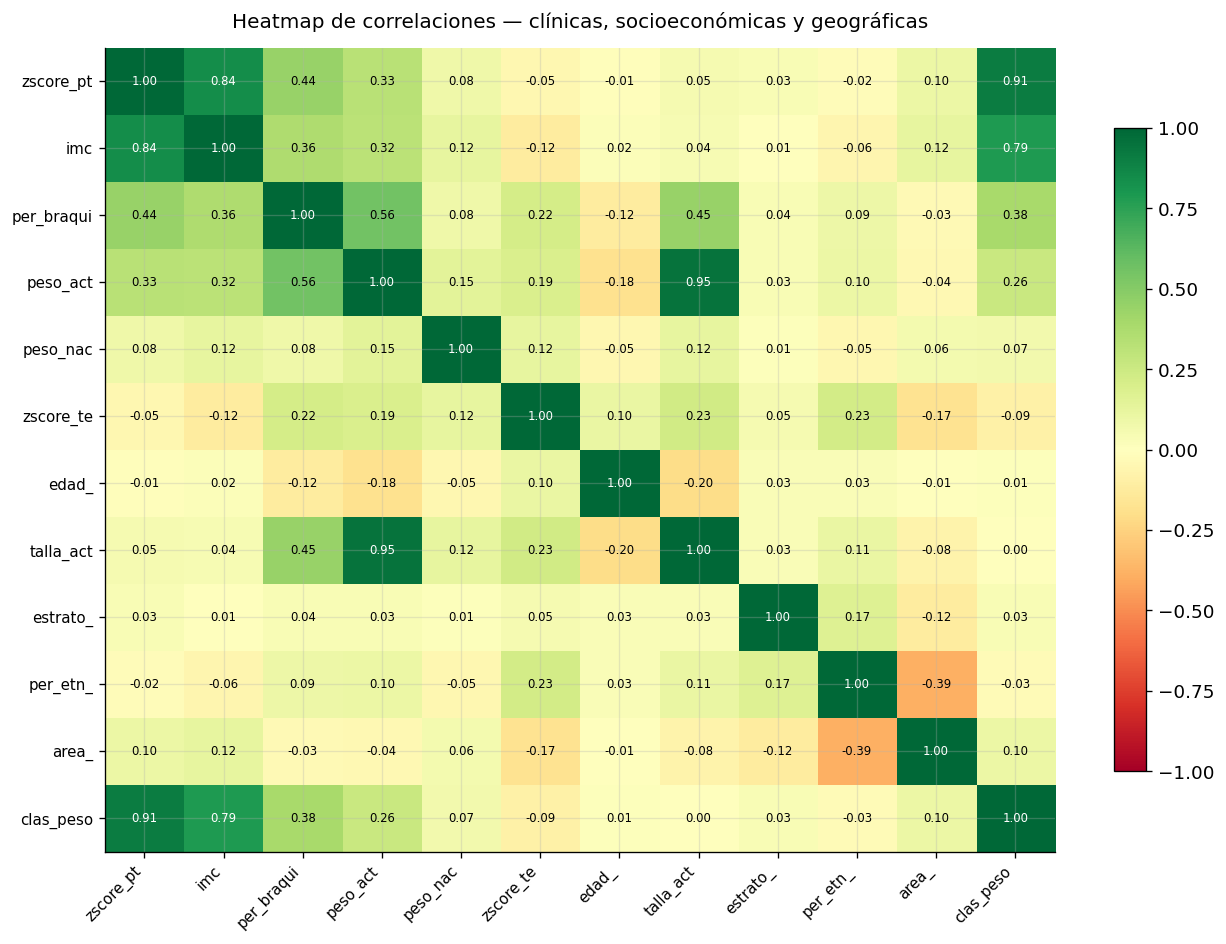

Nota clave: peso_act y talla_act tienen correlación ~0.95 entre sí (multicolinealidad).
En el modelado no se recomienda incluir ambas variables simultáneamente.


In [19]:
cols_heatmap = cols_corr + ['clas_peso']
corr_matrix  = df[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(cols_heatmap)))
ax.set_yticks(range(len(cols_heatmap)))
ax.set_xticklabels(cols_heatmap, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cols_heatmap, fontsize=9)
for i in range(len(cols_heatmap)):
    for j in range(len(cols_heatmap)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='black' if abs(val) < 0.7 else 'white')
ax.set_title('Heatmap de correlaciones — clínicas, socioeconómicas y geográficas', fontsize=12, pad=12)
plt.tight_layout()
plt.show()
print('Nota clave: peso_act y talla_act tienen correlación ~0.95 entre sí (multicolinealidad).')
print('En el modelado no se recomienda incluir ambas variables simultáneamente.')

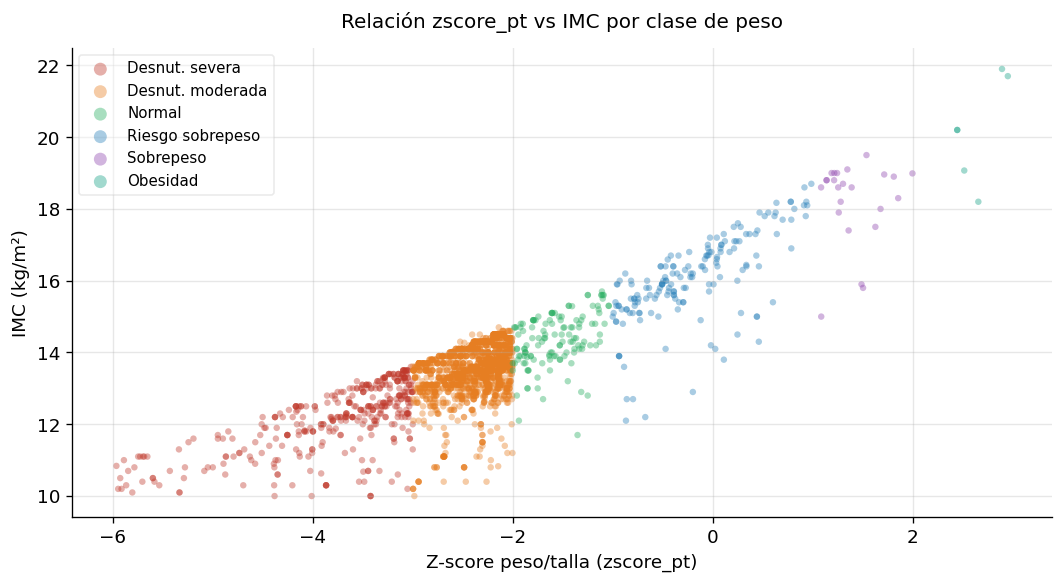

La separación visual entre nubes de puntos confirma que zscore_pt e imc
son los mejores predictores lineales de clas_peso.


In [20]:
sample = df.dropna(subset=['zscore_pt', 'imc', 'clas_peso_label'])
if len(sample) > 5000:
    sample = sample.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
for clase, color in COLORES_CLASE.items():
    sub = sample[sample['clas_peso_label'] == clase]
    ax.scatter(sub['zscore_pt'], sub['imc'], c=color, alpha=0.4, s=15, label=clase, edgecolors='none')
ax.set_title('Relación zscore_pt vs IMC por clase de peso', fontsize=12, pad=12)
ax.set_xlabel('Z-score peso/talla (zscore_pt)')
ax.set_ylabel('IMC (kg/m²)')
ax.legend(markerscale=2, framealpha=0.4, fontsize=9)
plt.tight_layout()
plt.show()
print('La separación visual entre nubes de puntos confirma que zscore_pt e imc')
print('son los mejores predictores lineales de clas_peso.')

---
## 10. Pruebas de normalidad

**¿Por qué hacerlas?** Antes de aplicar normalización hay que probar  
si los datos ya tienen distribución normal. Si la variable ya es normal, no debe normalizarse.

- **Shapiro-Wilk**: para muestras pequeñas (n ≤ 5000)  
- **Kolmogorov-Smirnov**: para muestras grandes  
- **Regla de decisión**: p-value > 0.05 → normal (no normalizar) | p-value ≤ 0.05 → no normal (normalizar)

In [21]:
cols_normalidad = ['zscore_pt', 'imc', 'per_braqui', 'peso_act',
                   'talla_act', 'peso_nac', 'edad_meses', 'zscore_te']
cols_normalidad = [c for c in cols_normalidad if c in df.columns]

resultados = []
for col in cols_normalidad:
    serie = df[col].dropna()
    n     = len(serie)
    if n <= 5000:
        stat, pval = stats.shapiro(serie.sample(min(n, 5000), random_state=42))
        test = 'Shapiro-Wilk'
    else:
        stat, pval = stats.kstest(serie, 'norm', args=(serie.mean(), serie.std()))
        test = 'Kolmogorov-Smirnov'
    es_normal = 'SI' if pval > 0.05 else 'NO'
    accion    = 'No normalizar' if pval > 0.05 else 'Normalizar (RobustScaler)'
    resultados.append({'Variable': col, 'Test': test, 'n': n,
                       'Estadístico': round(stat, 4), 'p-value': round(pval, 6),
                       'Normal': es_normal, 'Acción': accion})

df_normal = pd.DataFrame(resultados)
print('Resultados de pruebas de normalidad:')
print(df_normal.to_string(index=False))
print()
no_normales = df_normal[df_normal['Normal'] == 'NO']['Variable'].tolist()
normales    = df_normal[df_normal['Normal'] == 'SI']['Variable'].tolist()
print(f'Variables NO normales → aplicar RobustScaler en preparación de datos: {no_normales}')
print(f'Variables normales    → NO normalizar: {normales}')

Resultados de pruebas de normalidad:
  Variable         Test    n  Estadístico  p-value Normal                    Acción
 zscore_pt Shapiro-Wilk 2448       0.8616      0.0     NO Normalizar (RobustScaler)
       imc Shapiro-Wilk 2448       0.9058      0.0     NO Normalizar (RobustScaler)
per_braqui Shapiro-Wilk 2220       0.9704      0.0     NO Normalizar (RobustScaler)
  peso_act Shapiro-Wilk 2448       0.9801      0.0     NO Normalizar (RobustScaler)
 talla_act Shapiro-Wilk 2448       0.9812      0.0     NO Normalizar (RobustScaler)
  peso_nac Shapiro-Wilk 2448       0.7889      0.0     NO Normalizar (RobustScaler)
edad_meses Shapiro-Wilk 2448       0.7713      0.0     NO Normalizar (RobustScaler)
 zscore_te Shapiro-Wilk 2448       0.9770      0.0     NO Normalizar (RobustScaler)

Variables NO normales → aplicar RobustScaler en preparación de datos: ['zscore_pt', 'imc', 'per_braqui', 'peso_act', 'talla_act', 'peso_nac', 'edad_meses', 'zscore_te']
Variables normales    → NO normalizar

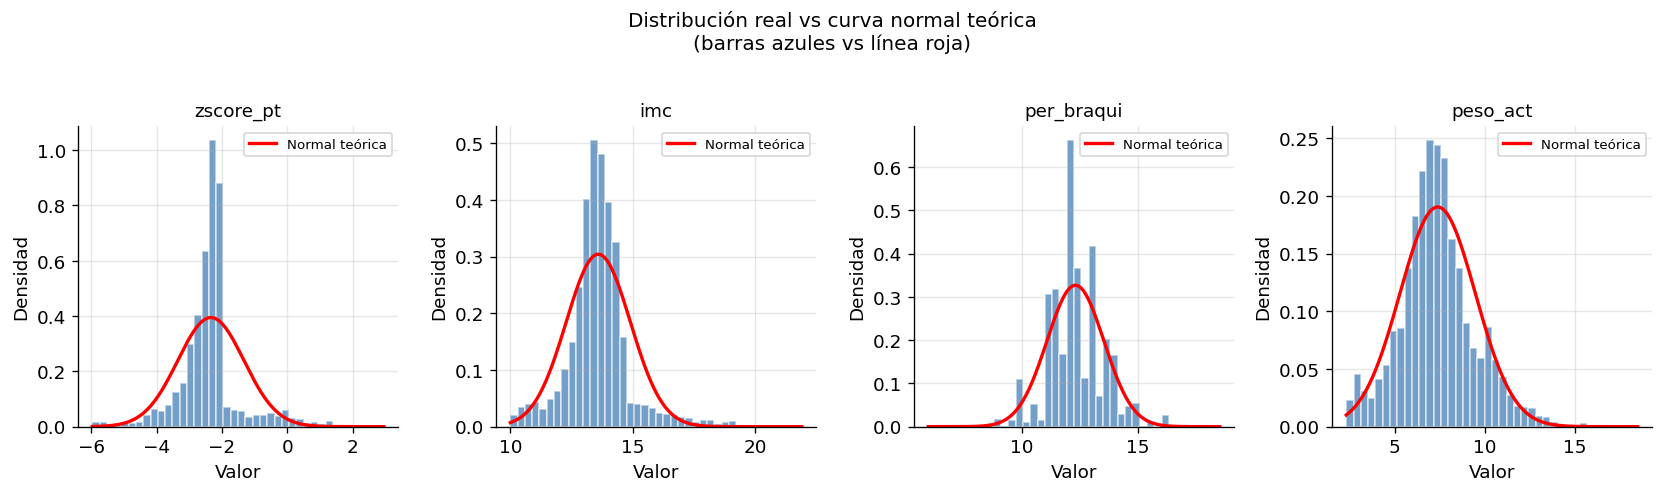

Si las barras azules siguen la curva roja: la variable es normal → no normalizar.
Si hay colas largas o múltiples picos: no es normal → aplicar RobustScaler.


In [22]:
cols_plot = [c for c in ['zscore_pt', 'imc', 'per_braqui', 'peso_act'] if c in df.columns]
fig, axes = plt.subplots(1, len(cols_plot), figsize=(14, 4))

for ax, col in zip(axes, cols_plot):
    serie = df[col].dropna()
    ax.hist(serie, bins=40, color='#185fa5', alpha=0.6, density=True, edgecolor='white')
    x = np.linspace(serie.min(), serie.max(), 200)
    ax.plot(x, stats.norm.pdf(x, serie.mean(), serie.std()), 'r-', linewidth=2, label='Normal teórica')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

fig.suptitle('Distribución real vs curva normal teórica\n(barras azules vs línea roja)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('Si las barras azules siguen la curva roja: la variable es normal → no normalizar.')
print('Si hay colas largas o múltiples picos: no es normal → aplicar RobustScaler.')

---
## 11. Análisis ANOVA — significancia estadística

**¿Por qué ANOVA?** Para determinar si las diferencias entre clases de peso son estadísticamente significativas para cada variable.  
Una variable con correlación baja puede aún ser significativa para discriminar entre grupos.

- **p-value < 0.05** → las diferencias entre clases son significativas para esa variable  
- **p-value ≥ 0.05** → no hay diferencia significativa → la variable probablemente no ayuda al modelo  
- **F alto** → mayor diferencia entre grupos → mejor predictor potencial

In [23]:
cols_anova = ['zscore_pt', 'imc', 'per_braqui', 'peso_act', 'talla_act',
              'peso_nac', 'edad_meses', 'zscore_te', 'estrato_']
cols_anova = [c for c in cols_anova if c in df.columns]

resultados_anova = []
for col in cols_anova:
    grupos = [df.loc[df['clas_peso_label'] == clase, col].dropna().values for clase in ORDEN]
    grupos = [g for g in grupos if len(g) > 1]
    if len(grupos) >= 2:
        stat, pval = stats.f_oneway(*grupos)
        sig = 'Sí (***)' if pval < 0.001 else ('Sí (*)' if pval < 0.05 else 'No')
        resultados_anova.append({'Variable': col, 'F-statistic': round(stat, 2),
                                  'p-value': round(pval, 6), 'Significativa': sig})

df_anova = pd.DataFrame(resultados_anova).sort_values('F-statistic', ascending=False)
print('Resultados ANOVA — diferencias entre clases de peso:')
print(df_anova.to_string(index=False))
print()
sig_vars   = df_anova[df_anova['Significativa'].str.startswith('Sí')]['Variable'].tolist()
nosig_vars = df_anova[df_anova['Significativa'] == 'No']['Variable'].tolist()
print(f'Variables significativas (p<0.05) → candidatas al modelo: {sig_vars}')
print(f'Variables NO significativas        → probablemente no aportan: {nosig_vars}')

Resultados ANOVA — diferencias entre clases de peso:
  Variable  F-statistic  p-value Significativa
 zscore_pt      2707.90 0.000000      Sí (***)
       imc       848.49 0.000000      Sí (***)
per_braqui        87.91 0.000000      Sí (***)
  peso_act        55.38 0.000000      Sí (***)
 talla_act        15.71 0.000000      Sí (***)
 zscore_te        13.06 0.000000      Sí (***)
edad_meses         5.87 0.000021      Sí (***)
  peso_nac         4.50 0.000435      Sí (***)
  estrato_         1.75 0.120266            No

Variables significativas (p<0.05) → candidatas al modelo: ['zscore_pt', 'imc', 'per_braqui', 'peso_act', 'talla_act', 'zscore_te', 'edad_meses', 'peso_nac']
Variables NO significativas        → probablemente no aportan: ['estrato_']


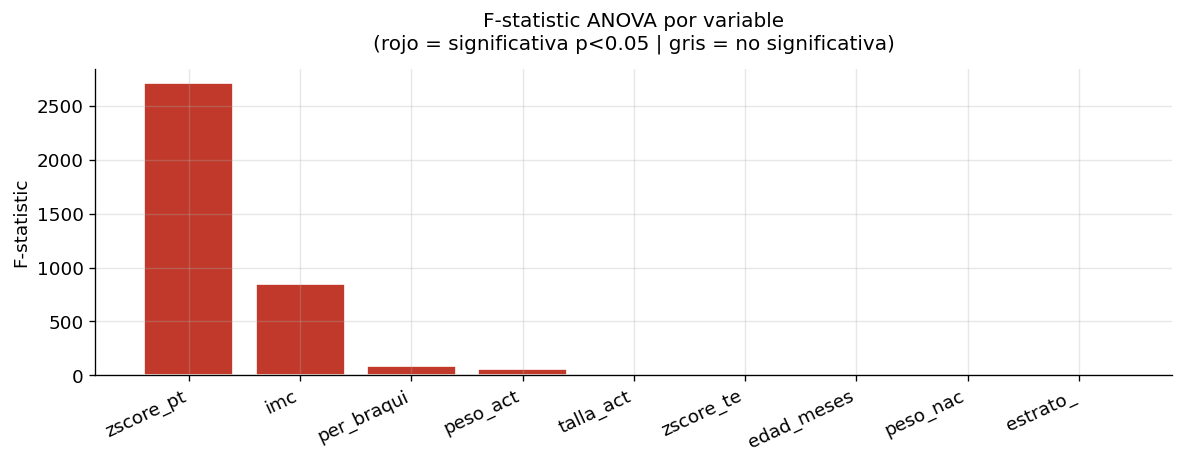

Variables con F alto y en rojo son las mejores candidatas para el modelo de clasificación.


In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
colores_f = ['#c0392b' if s.startswith('Sí') else '#95a5a6'
             for s in df_anova['Significativa']]
ax.bar(df_anova['Variable'], df_anova['F-statistic'], color=colores_f, edgecolor='white')
ax.set_title('F-statistic ANOVA por variable\n(rojo = significativa p<0.05 | gris = no significativa)',
             fontsize=12, pad=12)
ax.set_ylabel('F-statistic')
ax.set_xticklabels(df_anova['Variable'], rotation=25, ha='right')
plt.tight_layout()
plt.show()
print('Variables con F alto y en rojo son las mejores candidatas para el modelo de clasificación.')

---
## 12. Estadísticas descriptivas detalladas por clase de peso

In [25]:
cols_desc = ['edad_meses', 'peso_nac', 'talla_nac', 'edad_ges',
             'peso_act', 'talla_act', 'per_braqui', 'imc', 'zscore_pt', 'zscore_te']
cols_desc = [c for c in cols_desc if c in df.columns]

medias = df.groupby('clas_peso_label')[cols_desc].mean().reindex(ORDEN).round(2)
print('Medias por clase de peso:')
print(medias.to_string())

Medias por clase de peso:
                  edad_meses  peso_nac  talla_nac  edad_ges  peso_act  talla_act  per_braqui    imc  zscore_pt  zscore_te
clas_peso_label                                                                                                          
Desnut. severa         13.82   2709.70      47.71     38.15      6.03      69.75       11.41  12.15      -3.75      -2.92
Desnut. moderada       17.10   2779.10      48.67     38.50      7.55      74.09       12.35  13.52      -2.38      -2.65
Normal                 17.29   2736.84      48.00     38.36      7.50      71.65       12.45  14.35      -1.58      -3.29
Riesgo sobrepeso       15.45   2810.19      47.64     38.82      8.04      69.96       13.36  16.04      -0.20      -3.33
Sobrepeso              18.33   2851.33      46.67     38.58      9.97      72.57       14.56  18.22       1.41      -3.64
Obesidad               19.50   3007.83      48.00     39.17     11.88      75.42       14.33  20.21       2.65      -2.6

In [26]:
for clase in ORDEN:
    sub = df[df['clas_peso_label'] == clase][cols_desc]
    print(f'\n{"="*60}')
    print(f'  {clase.upper()}  —  {len(sub):,} registros')
    print(f'{"="*60}')
    print(sub.describe().round(3).to_string())


  DESNUT. SEVERA  —  379 registros
       edad_meses  peso_nac  talla_nac  edad_ges  peso_act  talla_act  per_braqui      imc  zscore_pt  zscore_te
count     379.000   379.000    161.000   379.000   379.000    379.000     328.000  379.000    379.000    379.000
mean       13.823  2709.698     47.708    38.148     6.033     69.751      11.406   12.154     -3.747     -2.917
std         9.901   389.497      3.535     2.012     1.654      9.213       1.294    0.917      0.719      1.693
min         1.000  1050.000     37.000    27.000     2.500     49.500       8.000   10.000     -5.964     -5.996
25%        10.000  2555.000     46.000    38.000     5.000     65.000      10.500   11.600     -4.091     -4.021
50%        12.000  2800.000     49.000    39.000     6.000     69.000      11.300   12.300     -3.504     -3.095
75%        12.000  2845.000     50.000    39.000     7.000     75.000      12.000   12.900     -3.190     -2.007
max        48.000  4000.000     55.000    40.000    12.000  

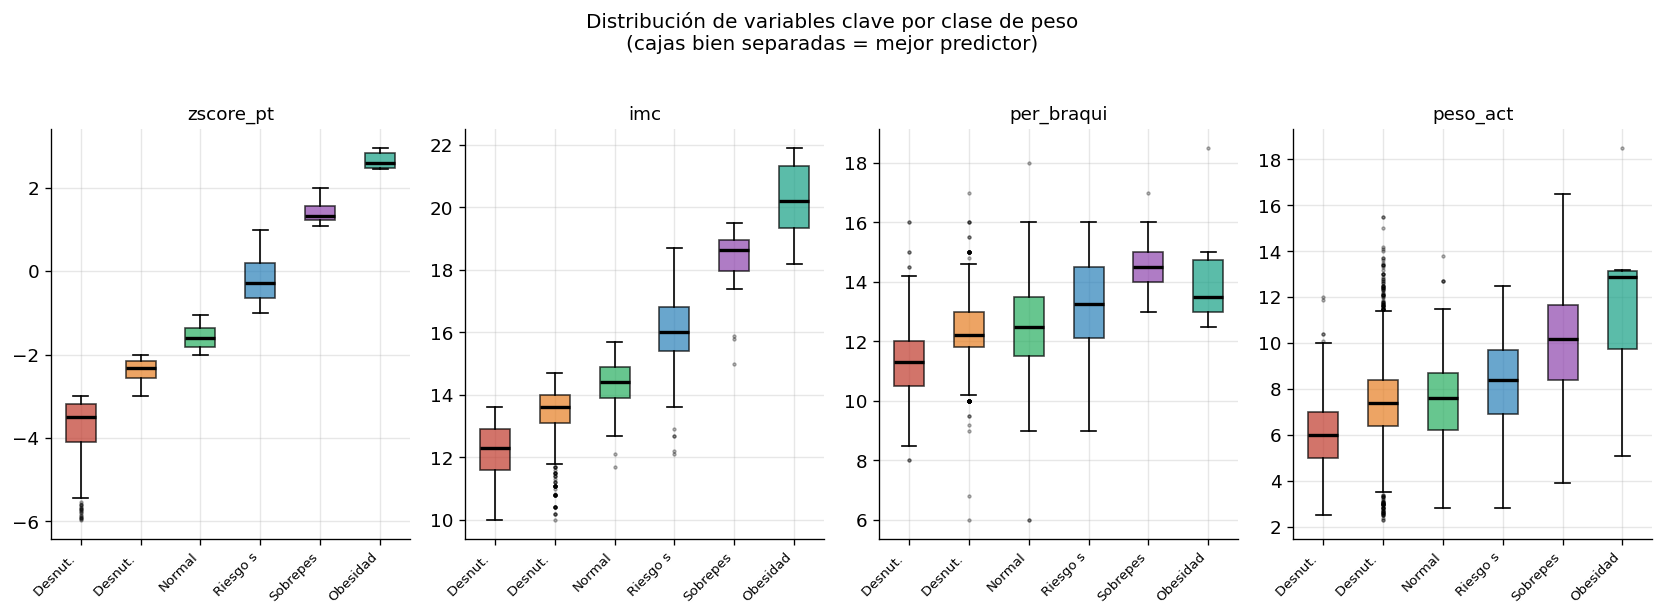

zscore_pt muestra cajas perfectamente separadas entre todas las clases → predictor más potente.
Los outliers en cada caja son casos clínicamente reales en condiciones atípicas para su clase.


In [27]:
vars_box = [c for c in ['zscore_pt', 'imc', 'per_braqui', 'peso_act'] if c in df.columns]

fig, axes = plt.subplots(1, len(vars_box), figsize=(14, 5))
for ax, var in zip(axes, vars_box):
    grupos = [df.loc[df['clas_peso_label'] == c, var].dropna().values for c in ORDEN]
    bp = ax.boxplot(grupos, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], COLORES_LISTA):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(var, fontsize=11)
    ax.set_xticks(range(1, len(ORDEN) + 1))
    ax.set_xticklabels([c[:8] for c in ORDEN], rotation=45, ha='right', fontsize=8)

fig.suptitle('Distribución de variables clave por clase de peso\n(cajas bien separadas = mejor predictor)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('zscore_pt muestra cajas perfectamente separadas entre todas las clases → predictor más potente.')
print('Los outliers en cada caja son casos clínicamente reales en condiciones atípicas para su clase.')

---
## 13. Hallazgos y próximos pasos

### Resumen de variables y su relación con `clas_peso`

| Variable | Tipo | Relación | Observación |
|---|---|---|---|
| `zscore_pt` | Clínica | Directamente proporcional (r≈0.91) | Predictor más fuerte |
| `imc` | Clínica | Directamente proporcional (r≈0.79) | Segundo predictor |
| `per_braqui` | Clínica | Directamente proporcional (r≈0.38) | Aporte moderado |
| `peso_act` | Clínica | Directamente proporcional (r≈0.26) | Aporte bajo |
| `zscore_te` | Clínica | Inversamente proporcional (r≈-0.09) | Mide talla, no peso |
| `estrato_` | Socioeconómica | Verificar en sección 7 | Proxy nivel económico |
| `municipio_origen` | Geográfica | Categórica | Alta variabilidad |
| `depto_origen` | Geográfica | Categórica | Cesar vs La Guajira |
| `per_etn_` / `etnia` | Étnica | Categórica | Indígenas: tasas más altas |
| `talla_act` | Clínica | ~0 con clas_peso | Multicolineal con peso_act |
| `edad_meses` | Demográfica | ~0 | No discrimina bien entre clases |

### Sobre normalización
- Se realizaron pruebas de normalidad en sección 10
- **Solo aplicar RobustScaler a las variables NO normales**
- Variables con distribución normal no deben normalizarse

### Sobre el desbalance de clases
- Más del 85% de los casos es desnutrición
- Requiere **SMOTE** o **`class_weight='balanced'`** en el modelado

### Investigacion de Variables externas 
- Número de hospitales / centros de salud por municipio
- Cobertura de agua potable por municipio
- Actividad económica principal del municipio
- Número de habitantes (para normalizar tasas por población)
- Índice de necesidades básicas insatisfechas (NBI) por municipio

### Próximos pasos (CRISP-DM fase 3 — Preparación de Datos)
1. Aplicar normalización selectiva según resultados de sección 10
2. Codificar variables categóricas (`municipio_origen`, `depto_origen`, `per_etn_`)
3. Evaluar si incluir `talla_act` dada su multicolinealidad con `peso_act`
4. Considerar incorporar variables externas para enriquecer el dataset
5. Siguiente notebook: `05_seleccion_features.ipynb` → PCA y selección de variables